In [1]:
import pathlib

import numpy as np
import pandas as pd
from pathlib import Path

from typing import List, Tuple, Dict, Optional
import pandas as pd
from pygments.lexer import combined
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score

from matplotlib import pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Feature engineering

## Functions

In [19]:
def build_title_feature(df: pd.DataFrame) -> pd.Series:
    title_feature = df["Name"].str.split(pat=",", expand=True)[1].str.split(pat=" ", expand=True)[1]
    return title_feature


def impute_age(df: pd.DataFrame) -> pd.DataFrame:

    child_median = df.loc[df["Age"] < 18, "Age"].median()
    adult_median = df.loc[df["Age"] >= 18, "Age"].median()
    global_median = df["Age"].median()

    child_median = child_median if pd.notna(child_median) else 5.0
    adult_median = adult_median if pd.notna(adult_median) else 28.0
    global_median = global_median if pd.notna(global_median) else 28.0

    conditions = [
        (df["Title"].isin(["Mrs.", "Miss."])) & df["Age"].isna(),
        (df["Title"] == "Master") & df["Age"].isna(),
        (df["Title"] == "Mr.") & df["Age"].isna()
    ]

    choices = [18.0, child_median, adult_median]

    df["Age"] = np.select(conditions, choices, default=df["Age"])
    df["Age"] = df["Age"].fillna(global_median)

    return df

def build_family_size_feature(df: pd.DataFrame) -> pd.Series:
    return df["SibSp"] + df["Parch"] + 1

def build_per_capita_fate_feature(df: pd.DataFrame) -> pd.Series:
    family_size = df.Family_size
    fare_per_person = df.Fare / family_size
    return fare_per_person

def build_per_capita_fate_cat_feature(df: pd.DataFrame) -> pd.Series:
    fare_per_person = df["Fare_per_person"]
    q = [0, .25, .75, 1]
    labels = [0,1,2]
    return pd.qcut(fare_per_person, q=q, labels=labels)

def build_is_father_feature(df: pd.DataFrame) -> pd.Series:
    return ((df["Parch"] > 0) & (df["Sex"] == "male") & (df["Title"] == "Mr.")).astype(int)

def build_is_mother_feature(df: pd.DataFrame) -> pd.Series:
    return ((df["Parch"] > 0) & (df["Sex"] == "female") & (df["Title"] == "Mrs.")).astype(int)

def build_ticket_group_size(df: pd.DataFrame) -> pd.Series:
    ticket_counts = df["Ticket"].value_counts()
    return df["Ticket"].map(ticket_counts)

def build_cabin_registered_flag(df: pd.DataFrame) -> pd.Series:
    return df["Cabin"].notnull().astype(int)

def build_cabin_shared_size(df: pd.DataFrame) -> pd.Series:
    valid_cabins = df["Cabin"].dropna()
    cabin_counts = valid_cabins.value_counts()
    return df["Cabin"].map(cabin_counts).fillna(0).astype(int)

def build_deck_feature(df: pd.DataFrame) -> pd.Series:
    return df["Cabin"].str[0].fillna("Unknown")

def build_embarked_imputed(df: pd.DataFrame) -> pd.Series:
    return df["Embarked"].fillna(df["Embarked"].mode()[0])

In [20]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["Embarked"] = build_embarked_imputed(df)
    df["Age_missing"] = df["Age"].isnull().astype(int)
    df["Title"] = build_title_feature(df)
    df = impute_age(df)
    df["Age_cat"] = pd.cut(df["Age"], bins=[float("-inf"), 16, 35, float("inf")], labels=["young", "adult", "old"])
    df["Family_size"] = build_family_size_feature(df)
    df["Fare_per_person"] = build_per_capita_fate_feature(df)
    df["Fare_per_person_cat"] = build_per_capita_fate_cat_feature(df)
    df["Is_Father"] = build_is_father_feature(df)
    df["Is_Mother"] = build_is_mother_feature(df)
    df["TicketGroupSize"] = build_ticket_group_size(df)
    df["CabinRegistered"] = build_cabin_registered_flag(df)
    df["CabinSharedSize"] = build_cabin_shared_size(df)
    df["Deck"] = build_deck_feature(df)

    return df

In [21]:
data_path = Path("data/titanic")
train_df = pd.read_csv(data_path / "train.csv")
test_df = pd.read_csv(data_path / "test.csv")

combined = pd.concat([train_df, test_df])
combined = engineer_features(combined)

train_df, test_df = combined.iloc[:len(train_df)], combined.iloc[len(train_df):]

## Visualisation

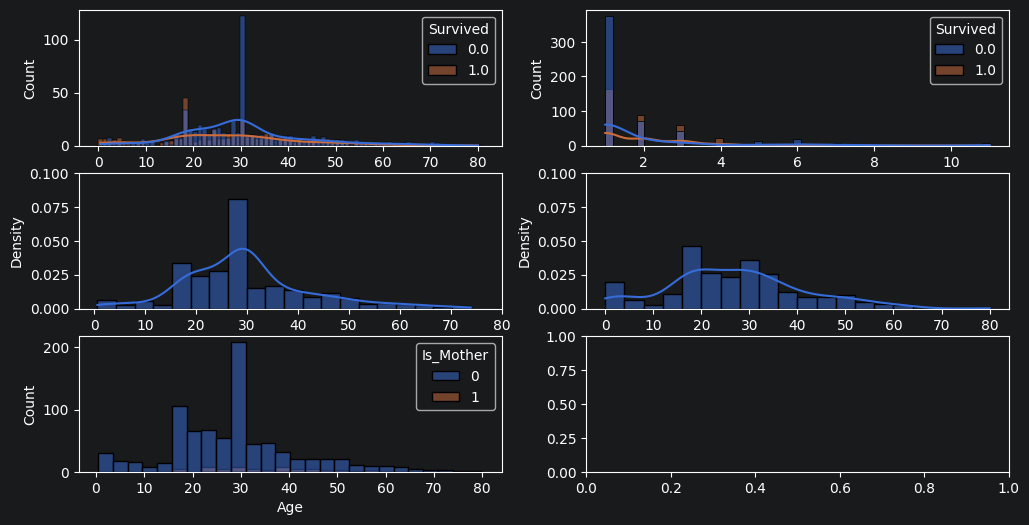

In [22]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(12, 6))

sns.histplot(x="Age", hue="Survived", data=train_df, discrete=True, kde=True, ax=axs[0,0])
sns.histplot(x="Age", data=train_df[train_df["Survived"]==0], stat="density", kde=True, ax=axs[1,0], bins=20)
sns.histplot(x="Age", data=train_df[train_df["Survived"]==1], stat="density", kde=True, ax=axs[1,1], bins=20)

sns.histplot(x="Family_size", hue="Survived", data=train_df, ax=axs[0,1], kde=True)

sns.histplot(x="Age", hue="Is_Mother", data=train_df, ax=axs[2,0])

ticks = np.linspace(train_df["Age"].min(), train_df["Age"].max(), 9)
for i in range(2):
    axs[1, i].set_xticks(ticks)
    axs[1, i].set_xticklabels([int(t) for t in ticks], rotation=0)
    axs[1, i].set_ylim(0, .1)

plt.show()

# Baseline model

## Features

In [23]:
numeric_features = [
    "Age", "SibSp", "Parch", "Fare",
    "Family_size", "Fare_per_person",
    "TicketGroupSize", "CabinSharedSize",
    "Age_missing", "Is_Father", "Is_Mother", "CabinRegistered"
]

categorical_features = [
    "Pclass", "Sex", "Embarked",
    "Title", "Age_cat", "Fare_per_person_cat", "Deck"
]

In [36]:
numeric_features_reduced = ["TicketGroupSize", "Age_missing"]
categorical_features_reduced = [
    "Pclass", "Sex", "Embarked", "Age_cat", "Fare_per_person_cat"
]

## Train and eval

In [37]:
def evaluate_and_train_single_model(
    estimator: BaseEstimator,
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5
) -> Tuple[BaseEstimator, float]:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # error_score='raise' forces the exact exception traceback to surface.
    # verbose=10 provides detailed progress logs for each fold.
    scores = cross_val_score(
        estimator, X, y,
        cv=cv,
        scoring="roc_auc",
        error_score='raise',
        verbose=10
    )

    mean_score = float(scores.mean())
    estimator.fit(X, y)
    return estimator, mean_score


def train_and_evaluate_all_models(
    estimators: Dict[str, BaseEstimator],
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5
) -> Tuple[Dict[str, BaseEstimator], pd.DataFrame]:
    fitted_models: Dict[str, BaseEstimator] = {}
    results: list[dict[str, str | float]] = []

    for name, estimator in estimators.items():
        print(f"\n--- Training {name} ---")
        fitted_model, score = evaluate_and_train_single_model(estimator, X, y, n_splits)
        fitted_models[name] = fitted_model
        results.append({"model": name, "roc_auc": score})

    results_df = pd.DataFrame(results).sort_values(by="roc_auc", ascending=False)
    return fitted_models, results_df

## XGBoost

In [38]:
def get_xgboost_pipeline(
    numeric_features: List[str],
    categorical_features: List[str]
) -> Pipeline:
    numeric_transformer = Pipeline(
        steps=[
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )
    preprocessor.set_output(transform="pandas")

    classifier = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier)
        ]
    )

## LightGBM

In [26]:
class CategoricalCaster(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_features: List[str]) -> None:
        self.categorical_features = categorical_features

    def fit(self, X: pd.DataFrame, y: Optional[pd.Series] = None) -> "CategoricalCaster":
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_transformed = X.copy()
        for column in self.categorical_features:
            X_transformed[column] = X_transformed[column].astype("category")
        return X_transformed


def get_lightgbm_pipeline(
    numeric_features: List[str],
    categorical_features: List[str]
) -> Pipeline:
    caster = CategoricalCaster(categorical_features)
    classifier = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    return Pipeline(steps=[("caster", caster), ("classifier", classifier)])

## CatBoost

In [27]:
def get_catboost_pipeline(
    numeric_features: List[str],
    categorical_features: List[str]
) -> Pipeline:
    caster = CategoricalCaster(categorical_features)
    start_idx = len(numeric_features)
    cat_indices = list(range(start_idx, start_idx + len(categorical_features)))

    classifier = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=5,
        l2_leaf_reg=3.0,
        random_seed=42,
        verbose=0,
        cat_features=cat_indices  # Pass integer indices to satisfy clone()
    )

    return Pipeline(
        steps=[
            ("caster", caster),
            ("classifier", classifier)
        ]
    )

# Train

In [44]:
x_train = train_df[numeric_features_reduced + categorical_features_reduced]
y_train = train_df["Survived"]

pipelines = {
    "XGBoost": get_xgboost_pipeline(numeric_features_reduced, categorical_features_reduced),
    "LightGBM": get_lightgbm_pipeline(numeric_features_reduced, categorical_features_reduced),
    }

fitted_models, evaluation_results = train_and_evaluate_all_models(pipelines, x_train, y_train)


--- Training XGBoost ---
[CV] START .....................................................................
[CV] END ................................ score: (test=0.902) total time=   0.2s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.2s


[CV] END ................................ score: (test=0.856) total time=   0.3s
[CV] START .....................................................................
[CV] END ................................ score: (test=0.872) total time=   0.2s
[CV] START .....................................................................
[CV] END ................................ score: (test=0.868) total time=   4.5s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    5.2s


[CV] END ................................ score: (test=0.866) total time=   5.7s


...

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    1.8s


[CV] END ................................ score: (test=0.850) total time=   0.2s
[CV] START .....................................................................
[CV] END ................................ score: (test=0.875) total time=   0.2s
[CV] START .....................................................................
[CV] END ................................ score: (test=0.879) total time=   0.4s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    2.6s


[CV] END ................................ score: (test=0.859) total time=   2.4s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    5.0s finished


In [45]:
evaluation_results

,model,roc_auc
1,LightGBM,0.873168
0,XGBoost,0.872762


# Submission

In [46]:
def generate_submissions(
    fitted_models: Dict[str, BaseEstimator],
    X_test: pd.DataFrame,
    passenger_ids: pd.Series
) -> None:
    for model_name, model in fitted_models.items():
        predictions = model.predict(X_test)

        submission = pd.DataFrame({
            "PassengerId": passenger_ids,
            "Survived": predictions
        })

        safe_name = model_name.replace(" ", "_").lower()
        file_path = Path(f"data/submissions/")
        if not file_path.exists():
            file_path.mkdir(parents=True)
        file_name = f"submission_{safe_name}.csv"
        submission.to_csv(file_path / file_name, index=False)
        print(f"Saved: {file_path}")

In [47]:
passenger_ids = test_df["PassengerId"]
X_test = test_df[numeric_features + categorical_features]

generate_submissions(fitted_models, X_test, passenger_ids)

Saved: data/submissions


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: Title: object, Deck: object

In [48]:
from kaggle.api.kaggle_api_extended import KaggleApi


def submit_file(file_path: Path, competition: str) -> None:
    api = KaggleApi()
    api.authenticate()
    message = file_path.stem.replace("submission_", "").replace("_", " ").title()
    api.competition_submit(
        file_name=str(file_path),
        message=message,
        competition=competition
    )
    print(f"Submitted {file_path.name} | Message: {message}")


def submit_directory(directory: Path, competition: str) -> None:
    for file_path in directory.glob("*.csv"):
        submit_file(file_path, competition)


submit_directory(Path("data/submissions"), "titanic")

100%|██████████| 3.59k/3.59k [00:00<00:00, 8.10kB/s]


HTTPError: 400 Client Error: Bad Request for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/CreateSubmission